Training Accuracy: 100.00%
Testing Accuracy: 100.00%

Classification Report (Testing):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        13

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix (Testing):
 [[17  0]
 [ 0 13]]
Confusion Matrix (Training):
 [[33  0]
 [ 0 37]]


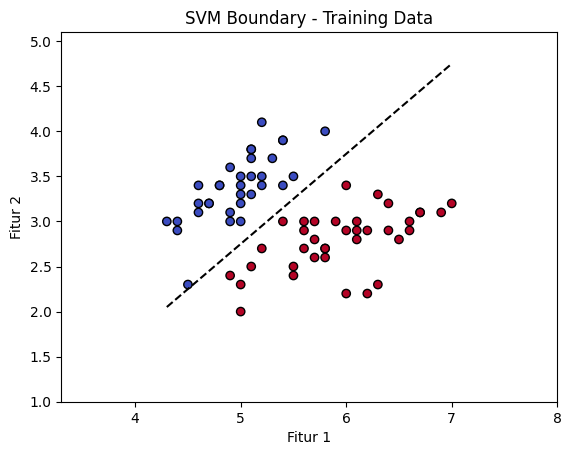

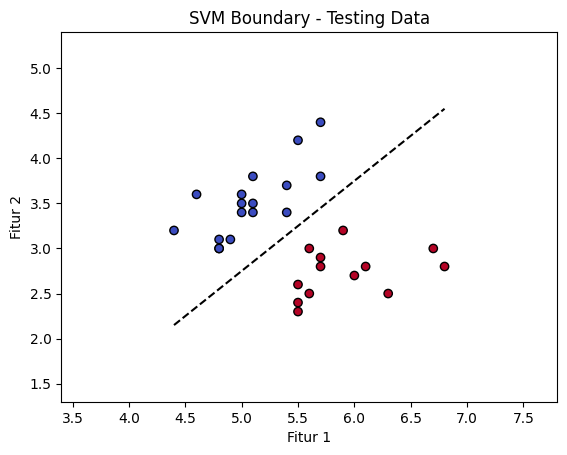

In [5]:
# Import library yang diperlukan
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset Iris dan pilih dua kelas pertama untuk klasifikasi biner
iris = datasets.load_iris()
X = iris.data[:, :2]  # Mengambil hanya dua fitur pertama
y = iris.target
y = y[y < 2]           # Memilih hanya dua kelas pertama (0 dan 1)
X = X[:len(y)]         # Mengambil data yang sesuai dengan dua kelas tersebut

# Membagi dataset menjadi data pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Membuat model SVM untuk klasifikasi biner
model = SVC(kernel='linear', C=1.0)  # kernel linear digunakan untuk pemisahan data linear
model.fit(X_train, y_train)

# Memprediksi label pada data pelatihan dan pengujian
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Evaluasi hasil pada data pelatihan dan pengujian
train_accuracy = accuracy_score(y_train, y_train_pred) * 100  # Akurasi dalam persen
test_accuracy = accuracy_score(y_test, y_test_pred) * 100      # Akurasi dalam persen

print(f"Training Accuracy: {train_accuracy:.2f}%")
print(f"Testing Accuracy: {test_accuracy:.2f}%")
print("\nClassification Report (Testing):\n", classification_report(y_test, y_test_pred))
print("Confusion Matrix (Testing):\n", confusion_matrix(y_test, y_test_pred))

# Tambahan: Matriks kebingungan untuk data pelatihan
print("Confusion Matrix (Training):\n", confusion_matrix(y_train, y_train_pred))

# Visualisasi hyperplane pada data pelatihan
def plot_svm_boundary(X, y, model, title="SVM dengan Hyperplane Linear"):
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')

    # Mendapatkan koefisien dan intercept dari model untuk membuat garis pemisah
    w = model.coef_[0]
    b = model.intercept_[0]
    x_points = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
    y_points = - (w[0] / w[1]) * x_points - b / w[1]
    plt.plot(x_points, y_points, color='black', linestyle='--')

    plt.xlabel("Fitur 1")
    plt.ylabel("Fitur 2")
    plt.title(title)
    plt.xlim(X[:, 0].min() - 1, X[:, 0].max() + 1)
    plt.ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)
    plt.show()

# Plot untuk data pelatihan
plot_svm_boundary(X_train, y_train, model, title="SVM Boundary - Training Data")

# Plot untuk data pengujian
plot_svm_boundary(X_test, y_test, model, title="SVM Boundary - Testing Data")
